# Exploration Data Analysis of Speech Dataset

## Load data

In [1]:
import sys
import os
sys.path.append(os.path.abspath("../.."))
from speech.dataset import load_pres
from utils import remove_numbers, find_uninformative_words, remove_accents, stemming_french
import re
from gensim.models import Word2Vec
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE

In [2]:
FILE_PATH = "../../../data/corpus.tache1.learn.utf8"
alltxts, alllabs, alldocids = load_pres(FILE_PATH)

print(f"Number of Mitterrand (1): {alllabs.count(1)}")
print(f"Number of Chirac (0): {alllabs.count(0)}")
print(f"Total lines: {len(alllabs)}")
print(len(alltxts))
print(alltxts[10])
print(alllabs[10])

Number of Mitterrand (1): 7523
Number of Chirac (0): 49890
Total lines: 57413
57413
A Brazzaville, que l'Afrique de demain se dessine.
0


## Preprocessing

In [3]:
from nltk.stem.snowball import FrenchStemmer
import re

stemmer = FrenchStemmer()

def stem_text(text):
    # Tokenize, stem each word, and join back
    tokens = re.findall(r'\w+', text.lower())
    return " ".join([stemmer.stem(w) for w in tokens])

In [ ]:
processed_txts = remove_numbers(alltxts)
uninformative_words = find_uninformative_words(processed_txts, alllabs, threshold=0.95)
# Get French stopwords as a list
french_stopwords = stopwords.words('french') + uninformative_words
# Remove their accents
french_stopwords_no_accents = [remove_accents(word) for word in french_stopwords]
#french_stopwords_stemmed = stemming_french(french_stopwords_no_accents)


# Add specific words that the standard NLTK list missed
manual_trash = [
    'celles', 'ceux', 'celui', 'celle',  # Demonstrative pronouns
    'memes', 'meme',                    # "Same"
    'vers', 'entre', 'sous',            # Prepositions
    'fait', 'faire', 'etre', 'avoir',   # Generic verbs
    'plus', 'aussi', 'tout', 'tous',     # Adverbs/Quantifiers
    'nom', 'date'
]

# Update stopword list
french_stopwords_final = list(set(french_stopwords_no_accents + manual_trash))
# ATTENTION: one sentence = one doc
vectorizer = TfidfVectorizer(
    lowercase=True,           # handles capitalization
    stop_words=french_stopwords_final,     # removes stop words (Pass the stop words list)
    max_df=0.15,             # ignore terms in >80% of docs
    min_df=15,                # ignore terms in <15 docs
    ngram_range=(1, 2),       # unigrams + bigrams,
    strip_accents='unicode'  # handles accents
)

X = vectorizer.fit_transform(processed_txts)

Filtering 449 uninformative/heavy words...


In [5]:
# Use the vectorizer's analyzer to get the exact same tokens used in X
analyze = vectorizer.build_analyzer()
sentences = [analyze(doc) for doc in processed_txts]

# Train Word2Vec with your requested parameters
from gensim.models import Word2Vec

model = Word2Vec(
    sentences, 
    vector_size=200, 
    window=10, 
    min_count=15,    # Match your min_df for consistency
    workers=4, 
    sample=0.001, 
    sg=0, 
    hs=0, 
    negative=5, 
    cbow_mean=1, 
    epochs=10        # Increased slightly since data is cleaner/smaller
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


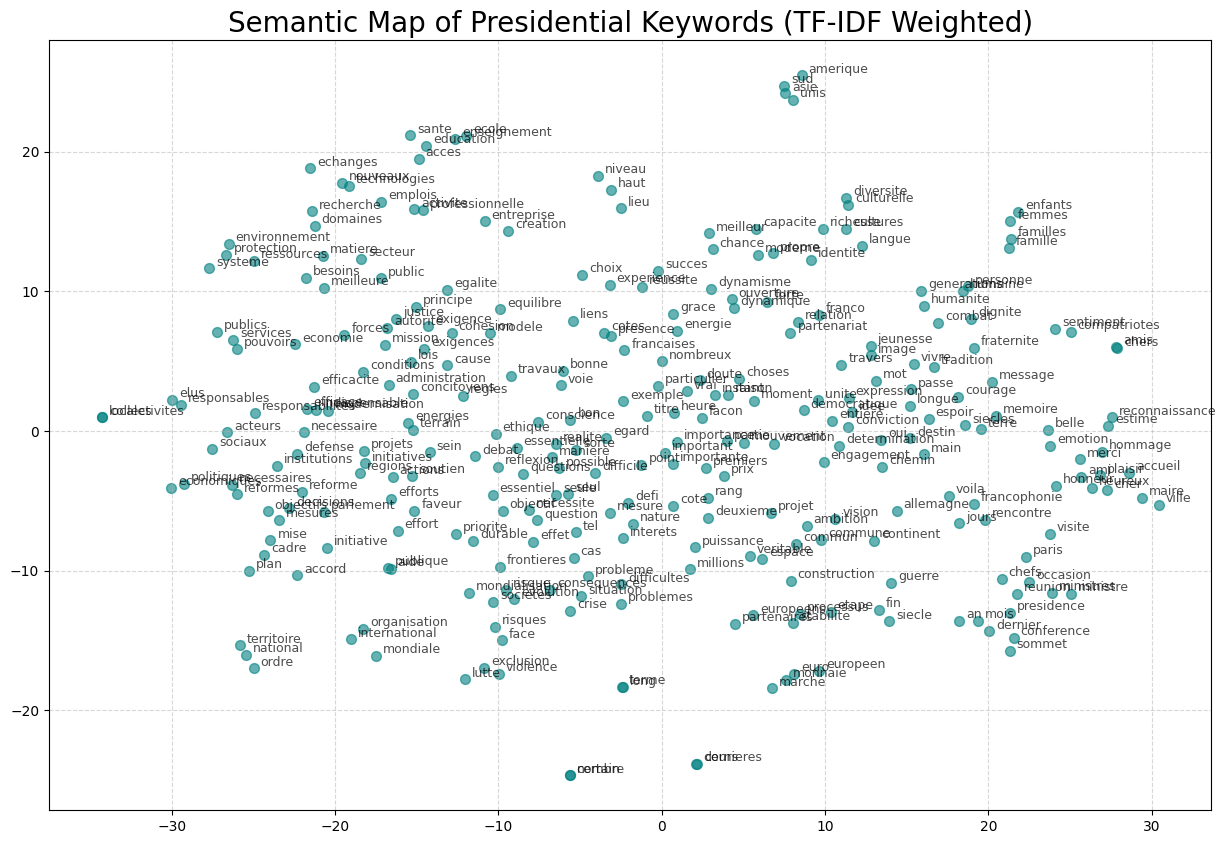

In [42]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

# --- STEP 1: Re-define the missing variables from your TF-IDF objects ---
# We get the word names from the vectorizer and their "importance" from the matrix X
feature_names = vectorizer.get_feature_names_out()
tfidf_sums = np.asarray(X.sum(axis=0)).flatten()

# We pick the top 300 most "important" words (highest TF-IDF sum)
top_indices = tfidf_sums.argsort()[-300:][::-1]

# --- STEP 2: Extract Word2Vec vectors for these specific words ---
# We only take words that actually made it into the Word2Vec vocabulary
top_words = [feature_names[i] for i in top_indices if feature_names[i] in model.wv]
word_vectors = np.array([model.wv[word] for word in top_words])

# --- STEP 3: Run t-SNE ---
tsne = TSNE(
    n_components=2, 
    perplexity=min(15, len(top_words) - 1), 
    init='pca', 
    learning_rate='auto',                  
    random_state=42
)
embeddings_2d = tsne.fit_transform(word_vectors)

# --- STEP 4: Enhanced Plot ---
plt.figure(figsize=(15, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], alpha=0.6, c='teal', s=50)

for i, word in enumerate(top_words):
    plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                 size=9, alpha=0.7, xytext=(5, 2), textcoords='offset points')

plt.title("Semantic Map of Presidential Keywords (TF-IDF Weighted)", fontsize=20)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

In [28]:
# 1. Separate counts by president
mitt_docs = [txt for txt, lab in zip(processed_txts, alllabs) if lab == 1]
chri_docs = [txt for txt, lab in zip(processed_txts, alllabs) if lab == 0]

# Flatten and count
from collections import Counter
mitt_counts = Counter(" ".join(mitt_docs).split())
chri_counts = Counter(" ".join(chri_docs).split())

# 2. Calculate a score for our top_words
# Score > 0 means Mitterrand uses it more; Score < 0 means Chirac uses it more
word_scores = []
for word in top_words:
    # Normalize by total docs to handle the class imbalance (Chirac has way more docs)
    f_mitt = mitt_counts[word] / len(mitt_docs)
    f_chri = chri_counts[word] / len(chri_docs)
    
    # Simple log ratio or difference
    score = (f_mitt - f_chri) / (f_mitt + f_chri + 1e-6) 
    word_scores.append(score)

word_scores = np.array(word_scores)

/var/folders/my/27r6mb7d4sg2pyvcl7qgcf680000gn/T/ipykernel_13372/2834008257.py:19: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=14)


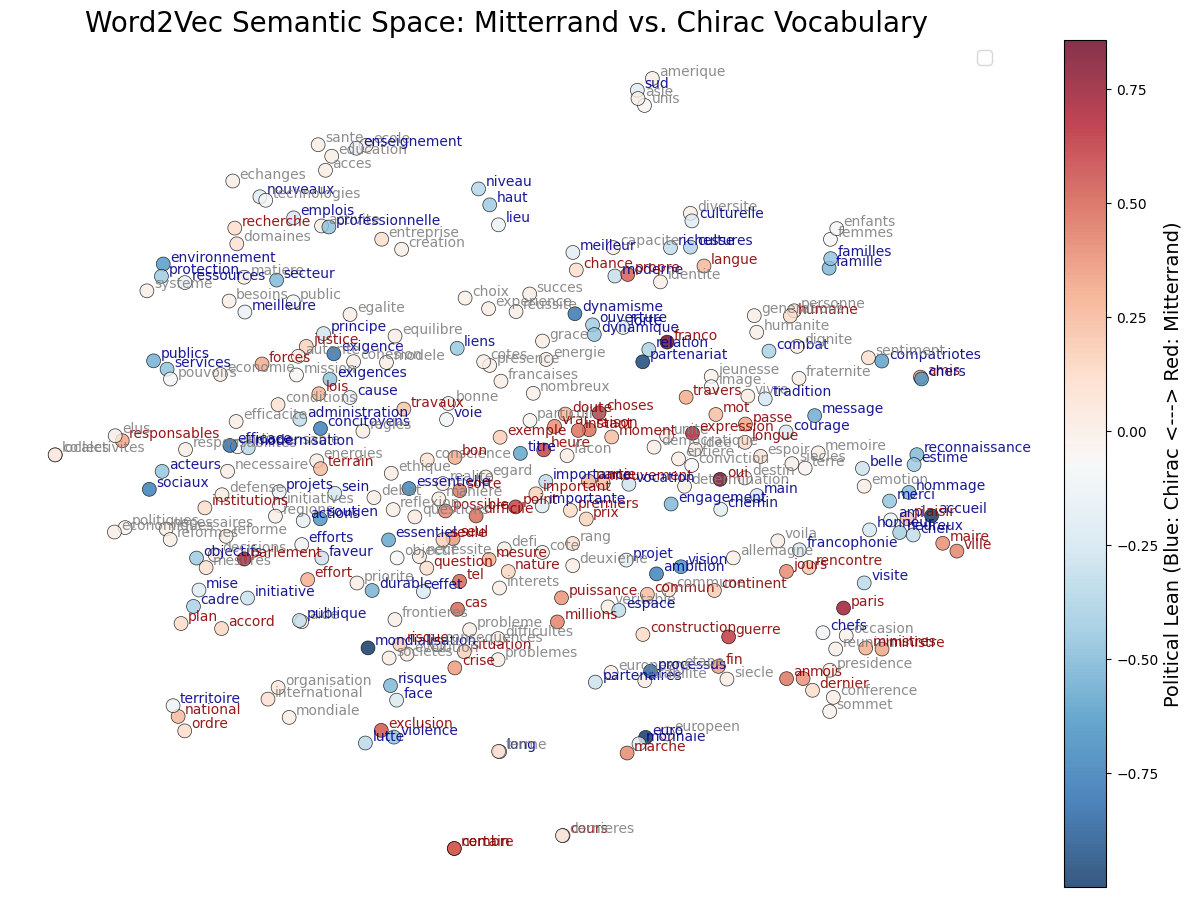

In [41]:
plt.figure(figsize=(16, 11))

# Use a diverging colormap (RdBu: Red for Positive/Mitterrand, Blue for Negative/Chirac)
scatter = plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], 
                      c=word_scores, cmap='RdBu_r', s=100, 
                      edgecolors='black', linewidth=0.5, alpha=0.8)

# Add labels with colors matching their 'lean'
for i, word in enumerate(top_words):
    color = 'darkred' if word_scores[i] > 0.1 else ('darkblue' if word_scores[i] < -0.1 else 'gray')
    plt.annotate(word, (embeddings_2d[i, 0], embeddings_2d[i, 1]), 
                 size=10, color=color, alpha=0.9,
                 xytext=(5, 2), textcoords='offset points')

cbar = plt.colorbar(scatter)
cbar.set_label('Political Lean (Blue: Chirac <---> Red: Mitterrand)', fontsize=14)
plt.title("Word2Vec Semantic Space: Mitterrand vs. Chirac Vocabulary", fontsize=20)
plt.axis('off') # Cleaner look for clusters
plt.legend(fontsize=14)
plt.show()

## Plotting Zipf's Law

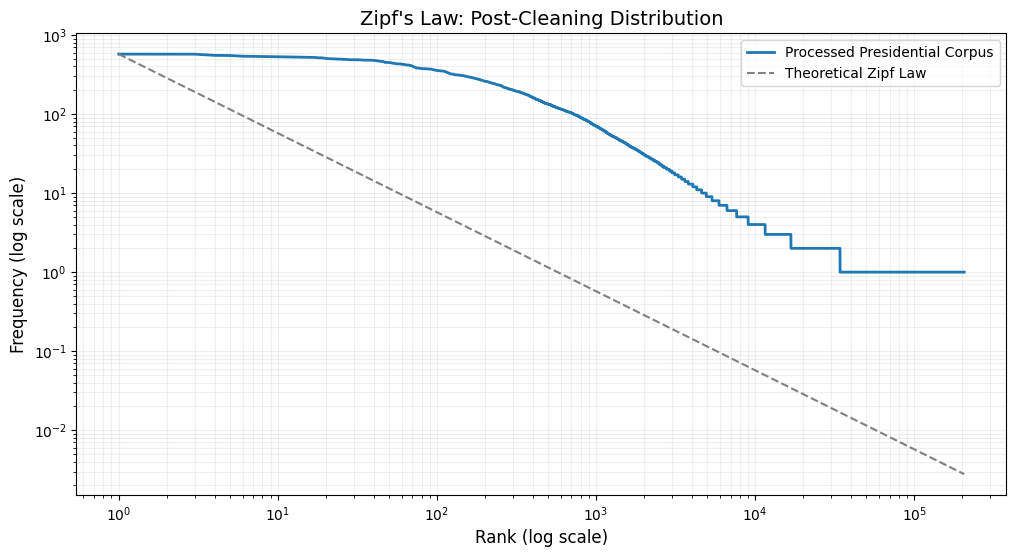

Unique tokens after cleaning: 206007
Top 5 most frequent terms: [('economie', 573), ('heure', 572), ('moment', 572), ('paris', 553), ('efforts', 550)]


In [31]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# 1. Re-tokenize the processed text to get word frequencies
# We use the vectorizer's analyzer to ensure we match your TF-IDF vocabulary
analyze = vectorizer.build_analyzer()
all_tokens = [token for doc in processed_txts_pos for token in analyze(doc)]
word_counts = Counter(all_tokens)

# 2. Prepare data for plotting
most_common = word_counts.most_common()
frequencies = np.array([count for word, count in most_common])
ranks = np.arange(1, len(frequencies) + 1)

# 3. Visualization
plt.figure(figsize=(12, 6))

# Log-Log Plot
plt.loglog(ranks, frequencies, label='Processed Presidential Corpus', linewidth=2)

# Add a theoretical Zipf line (1/x) for comparison
# We anchor it to the first data point
theoretical_zipf = frequencies[0] / ranks
plt.loglog(ranks, theoretical_zipf, color='gray', linestyle='--', label='Theoretical Zipf Law')

plt.title("Zipf's Law: Post-Cleaning Distribution", fontsize=14)
plt.xlabel("Rank (log scale)", fontsize=12)
plt.ylabel("Frequency (log scale)", fontsize=12)
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.2)

plt.show()

# Print some stats for sanity check
print(f"Unique tokens after cleaning: {len(word_counts)}")
print(f"Top 5 most frequent terms: {most_common[:5]}")

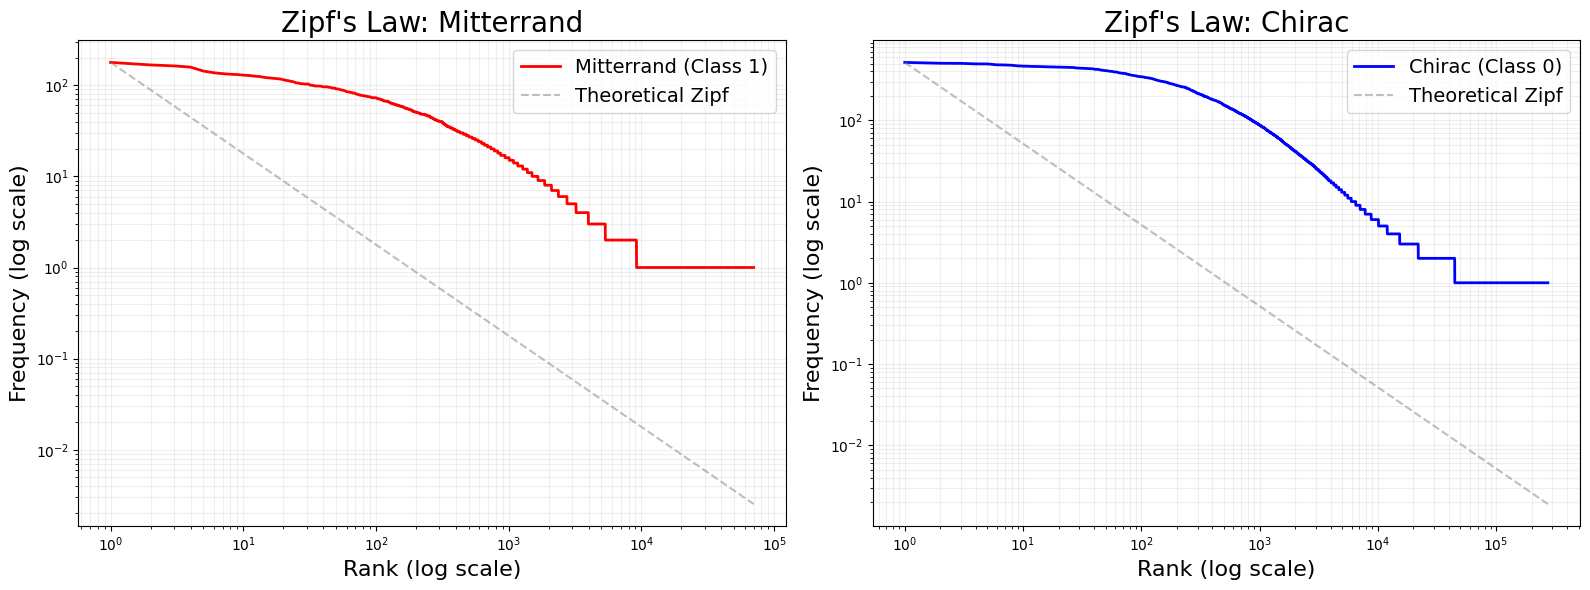

MITTERRAND TOP 10              | CHIRAC TOP 10                 
-----------------------------------------------------------------
facon (178)                    | economie (517)                
crois (167)                    | ambition (505)                
point (163)                    | demain (503)                  
cas (158)                      | environnement (496)           
moins (143)                    | cadre (495)                   
simplement (137)               | efforts (483)                 
ville (134)                    | partenaires (481)             
moment (132)                   | heure (477)                   
reste (131)                    | forte (469)                   
plan (129)                     | entreprise (465)              


In [38]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# 1. Get the analyzer from your vectorizer (includes stemming & stopword logic)
analyze = vectorizer.build_analyzer()

# 2. Separate documents and analyze tokens for each class
mitt_docs = [txt for txt, lab in zip(processed_txts, alllabs) if lab == 1]
chri_docs = [txt for txt, lab in zip(processed_txts, alllabs) if lab == 0]

mitt_tokens = [token for doc in mitt_docs for token in analyze(doc)]
chri_tokens = [token for doc in chri_docs for token in analyze(doc)]

mitt_counts = Counter(mitt_tokens)
chri_counts = Counter(chri_tokens)

# 3. Prepare data for plotting
def get_zipf_data(counts):
    most_common = counts.most_common()
    freqs = np.array([count for _, count in most_common])
    ranks = np.arange(1, len(freqs) + 1)
    return ranks, freqs, most_common

r_mitt, f_mitt, top_mitt = get_zipf_data(mitt_counts)
r_chri, f_chri, top_chri = get_zipf_data(chri_counts)

# 4. Visualization: Side-by-Side Zipf Plots
plt.figure(figsize=(16, 6))

# Subplot for Mitterrand
plt.subplot(1, 2, 1)
plt.loglog(r_mitt, f_mitt, label='Mitterrand (Class 1)', color='red', linewidth=2)
plt.loglog(r_mitt, f_mitt[0] / r_mitt, color='gray', linestyle='--', alpha=0.5, label='Theoretical Zipf')
plt.title("Zipf's Law: Mitterrand", fontsize=20)
plt.xlabel("Rank (log scale)", fontsize=16)
plt.ylabel("Frequency (log scale)", fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, which="both", alpha=0.2)

# Subplot for Chirac
plt.subplot(1, 2, 2)
plt.loglog(r_chri, f_chri, label='Chirac (Class 0)', color='blue', linewidth=2)
plt.loglog(r_chri, f_chri[0] / r_chri, color='gray', linestyle='--', alpha=0.5, label='Theoretical Zipf')
plt.title("Zipf's Law: Chirac", fontsize=20)
plt.xlabel("Rank (log scale)", fontsize=16)
plt.ylabel("Frequency (log scale)", fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, which="both", alpha=0.2)

plt.tight_layout()
plt.show()

# 5. Print Comparison of Top 10 words
print(f"{'MITTERRAND TOP 10':<30} | {'CHIRAC TOP 10':<30}")
print("-" * 65)
for i in range(10):
    m_word = f"{top_mitt[i][0]} ({top_mitt[i][1]})"
    c_word = f"{top_chri[i][0]} ({top_chri[i][1]})"
    print(f"{m_word:<30} | {c_word:<30}")

In [18]:
processed_txts = remove_numbers(alltxts)
uninformative_words = find_uninformative_words(processed_txts, alllabs, threshold=0.95)
# Get French stopwords as a list
french_stopwords = stopwords.words('french') + uninformative_words
# Remove their accents
french_stopwords_no_accents = [remove_accents(word) for word in french_stopwords]
#french_stopwords_stemmed = stemming_french(french_stopwords_no_accents)


# Add specific words that the standard NLTK list missed
manual_trash = [
    'celles', 'ceux', 'celui', 'celle',  # Demonstrative pronouns
    'memes', 'meme',                    # "Same"
    'vers', 'entre', 'sous',            # Prepositions
    'fait', 'faire', 'etre', 'avoir',   # Generic verbs
    'plus', 'aussi', 'tout', 'tous',     # Adverbs/Quantifiers
    'nom', 'date', 'autres'
]

# Update stopword list
french_stopwords_final = list(set(french_stopwords_no_accents + manual_trash))

import spacy

# Load French model
nlp = spacy.load("fr_core_news_sm", disable=["ner", "parser"])

def filter_pos(text):
    doc = nlp(text)
    # Only keep Nouns, Proper Nouns, and Adjectives
    # This keeps "economie" and "ambition" but drops "simplement" and "crois"
    cleaned = [token.text for token in doc if token.pos_ in ['NOUN', 'PROPN', 'ADJ']]
    return " ".join(cleaned)

# Apply to your text (this might take a minute depending on corpus size)
processed_txts_pos = [filter_pos(txt) for txt in processed_txts]

Filtering 449 uninformative/heavy words...


In [22]:
# ATTENTION: one sentence = one doc
vectorizer = TfidfVectorizer(
    lowercase=True,           # handles capitalization
    stop_words=french_stopwords_final,     # removes stop words (Pass the stop words list)
    max_df=0.10,          
    min_df=10,            
    ngram_range=(1, 2),  
    strip_accents='unicode'  # handles accents
)

X = vectorizer.fit_transform(processed_txts_pos)


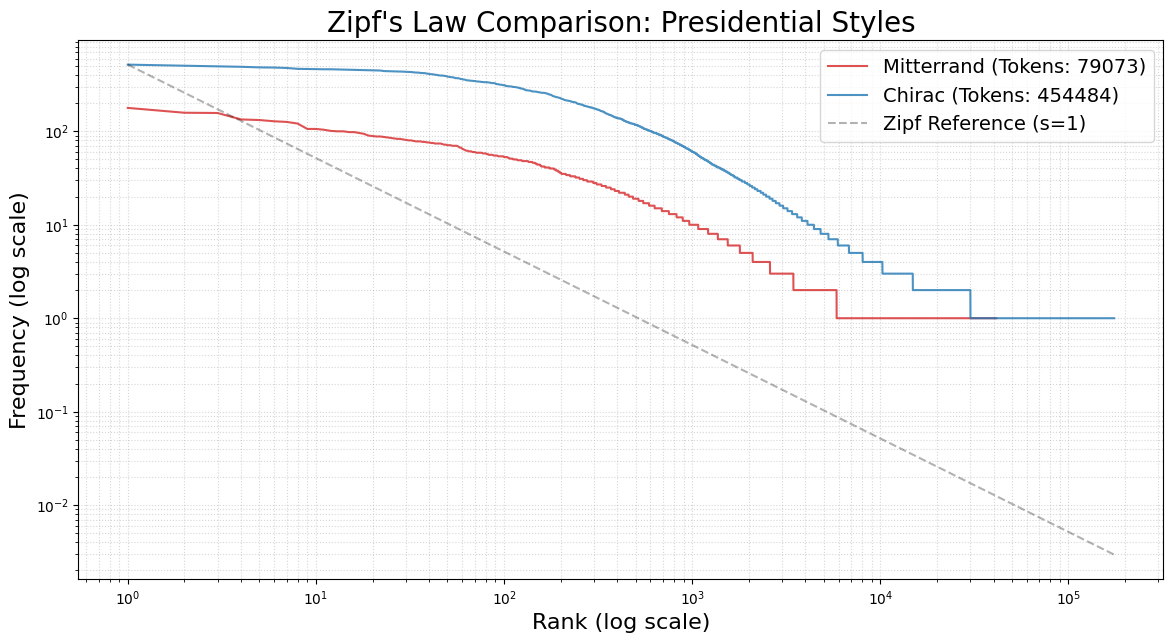

MITTERRAND TOP 10              | CHIRAC TOP 10                 
-----------------------------------------------------------------
facon (178)                    | economie (517)                
crois (167)                    | ambition (505)                
point (163)                    | demain (503)                  
cas (158)                      | environnement (496)           
moins (143)                    | cadre (495)                   
simplement (137)               | efforts (483)                 
ville (134)                    | partenaires (481)             
moment (132)                   | heure (477)                   
reste (131)                    | forte (469)                   
plan (129)                     | entreprise (465)              


In [39]:
import matplotlib.pyplot as plt
from collections import Counter
import numpy as np

# 1. Use the analyzer to get cleaned tokens for each class
analyze = vectorizer.build_analyzer()

mitt_docs = [txt for txt, lab in zip(processed_txts_pos, alllabs) if lab == 1]
chri_docs = [txt for txt, lab in zip(processed_txts_pos, alllabs) if lab == 0]

mitt_counts = Counter([token for doc in mitt_docs for token in analyze(doc)])
chri_counts = Counter([token for doc in chri_docs for token in analyze(doc)])

# 2. Function to extract Zipf metrics
def get_zipf_metrics(counts):
    freqs = np.array(sorted(counts.values(), reverse=True))
    ranks = np.arange(1, len(freqs) + 1)
    return ranks, freqs

r_m, f_m = get_zipf_metrics(mitt_counts)
r_c, f_c = get_zipf_metrics(chri_counts)

# 3. Plotting
plt.figure(figsize=(14, 7))

# Plot Mitterrand
plt.loglog(r_m, f_m, label=f'Mitterrand (Tokens: {sum(mitt_counts.values())})', color='tab:red', alpha=0.8)
# Plot Chirac
plt.loglog(r_c, f_c, label=f'Chirac (Tokens: {sum(chri_counts.values())})', color='tab:blue', alpha=0.8)

# Add one shared theoretical line for reference
plt.loglog(r_c, f_c[0] / r_c, color='black', linestyle='--', alpha=0.3, label='Zipf Reference (s=1)')

plt.title("Zipf's Law Comparison: Presidential Styles", fontsize=20)
plt.xlabel("Rank (log scale)", fontsize=16)
plt.ylabel("Frequency (log scale)", fontsize=16)
plt.legend(fontsize=14)
plt.grid(True, which="both", linestyle=':', alpha=0.5)

plt.show()

# 5. Print Comparison of Top 10 words
print(f"{'MITTERRAND TOP 10':<30} | {'CHIRAC TOP 10':<30}")
print("-" * 65)
for i in range(10):
    m_word = f"{top_mitt[i][0]} ({top_mitt[i][1]})"
    c_word = f"{top_chri[i][0]} ({top_chri[i][1]})"
    print(f"{m_word:<30} | {c_word:<30}")

In [25]:
# Use the vectorizer's analyzer to get the exact same tokens used in X
analyze = vectorizer.build_analyzer()
sentences = [analyze(doc) for doc in processed_txts_pos]

# Train Word2Vec with your requested parameters
from gensim.models import Word2Vec

model = Word2Vec(
    sentences, 
    vector_size=200, 
    window=10, 
    min_count=15,    # Match your min_df for consistency
    workers=4, 
    sample=0.001, 
    sg=0, 
    hs=0, 
    negative=5, 
    cbow_mean=1, 
    epochs=10        # Increased slightly since data is cleaner/smaller
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


## Visualize embeddings

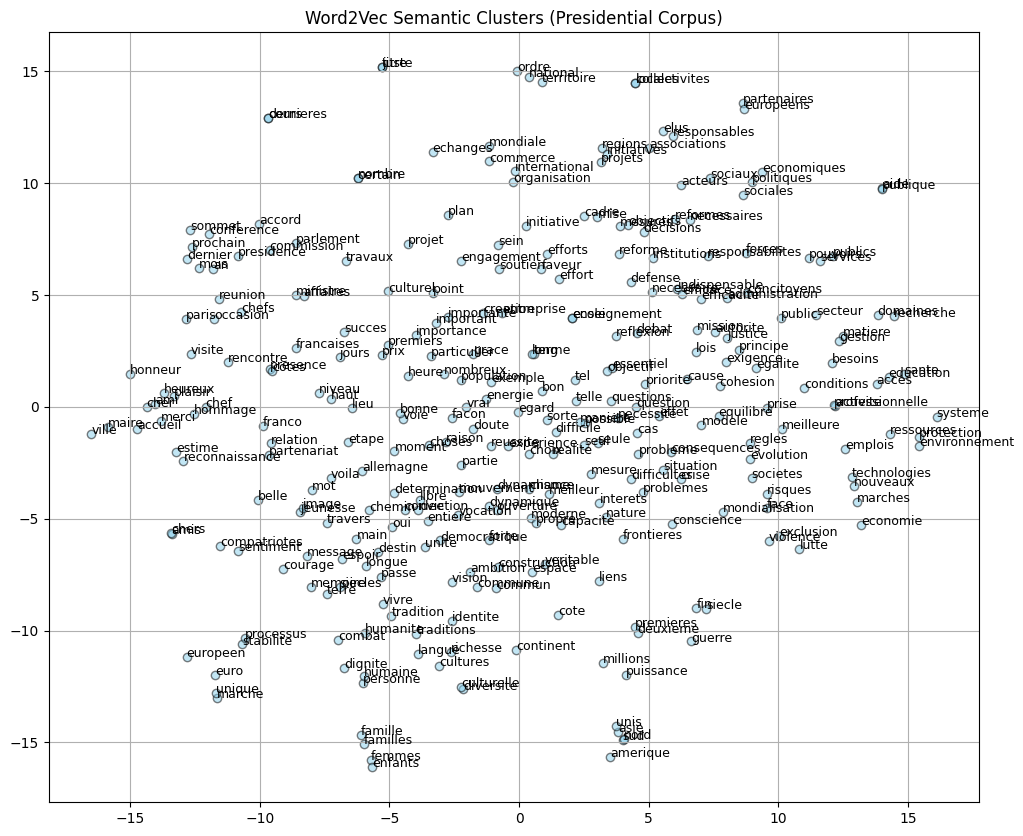

In [26]:
def visualize_embeddings(model, limit=300):
    # Extract vectors and labels for the top 'limit' words
    words = list(model.wv.index_to_key)[:limit]
    vectors = np.array([model.wv[word] for word in words])
    
    # Reduce to 2D using t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=30)
    vectors_2d = tsne.fit_transform(vectors)
    
    # Plotting
    plt.figure(figsize=(12, 10))
    plt.scatter(vectors_2d[:, 0], vectors_2d[:, 1], alpha=0.5, edgecolors='k', c='skyblue')
    
    for i, word in enumerate(words):
        plt.annotate(word, xy=(vectors_2d[i, 0], vectors_2d[i, 1]), size=9)
        
    plt.title("Word2Vec Semantic Clusters (Presidential Corpus)")
    plt.grid(True)
    plt.show()

visualize_embeddings(model)

## Word Cloud

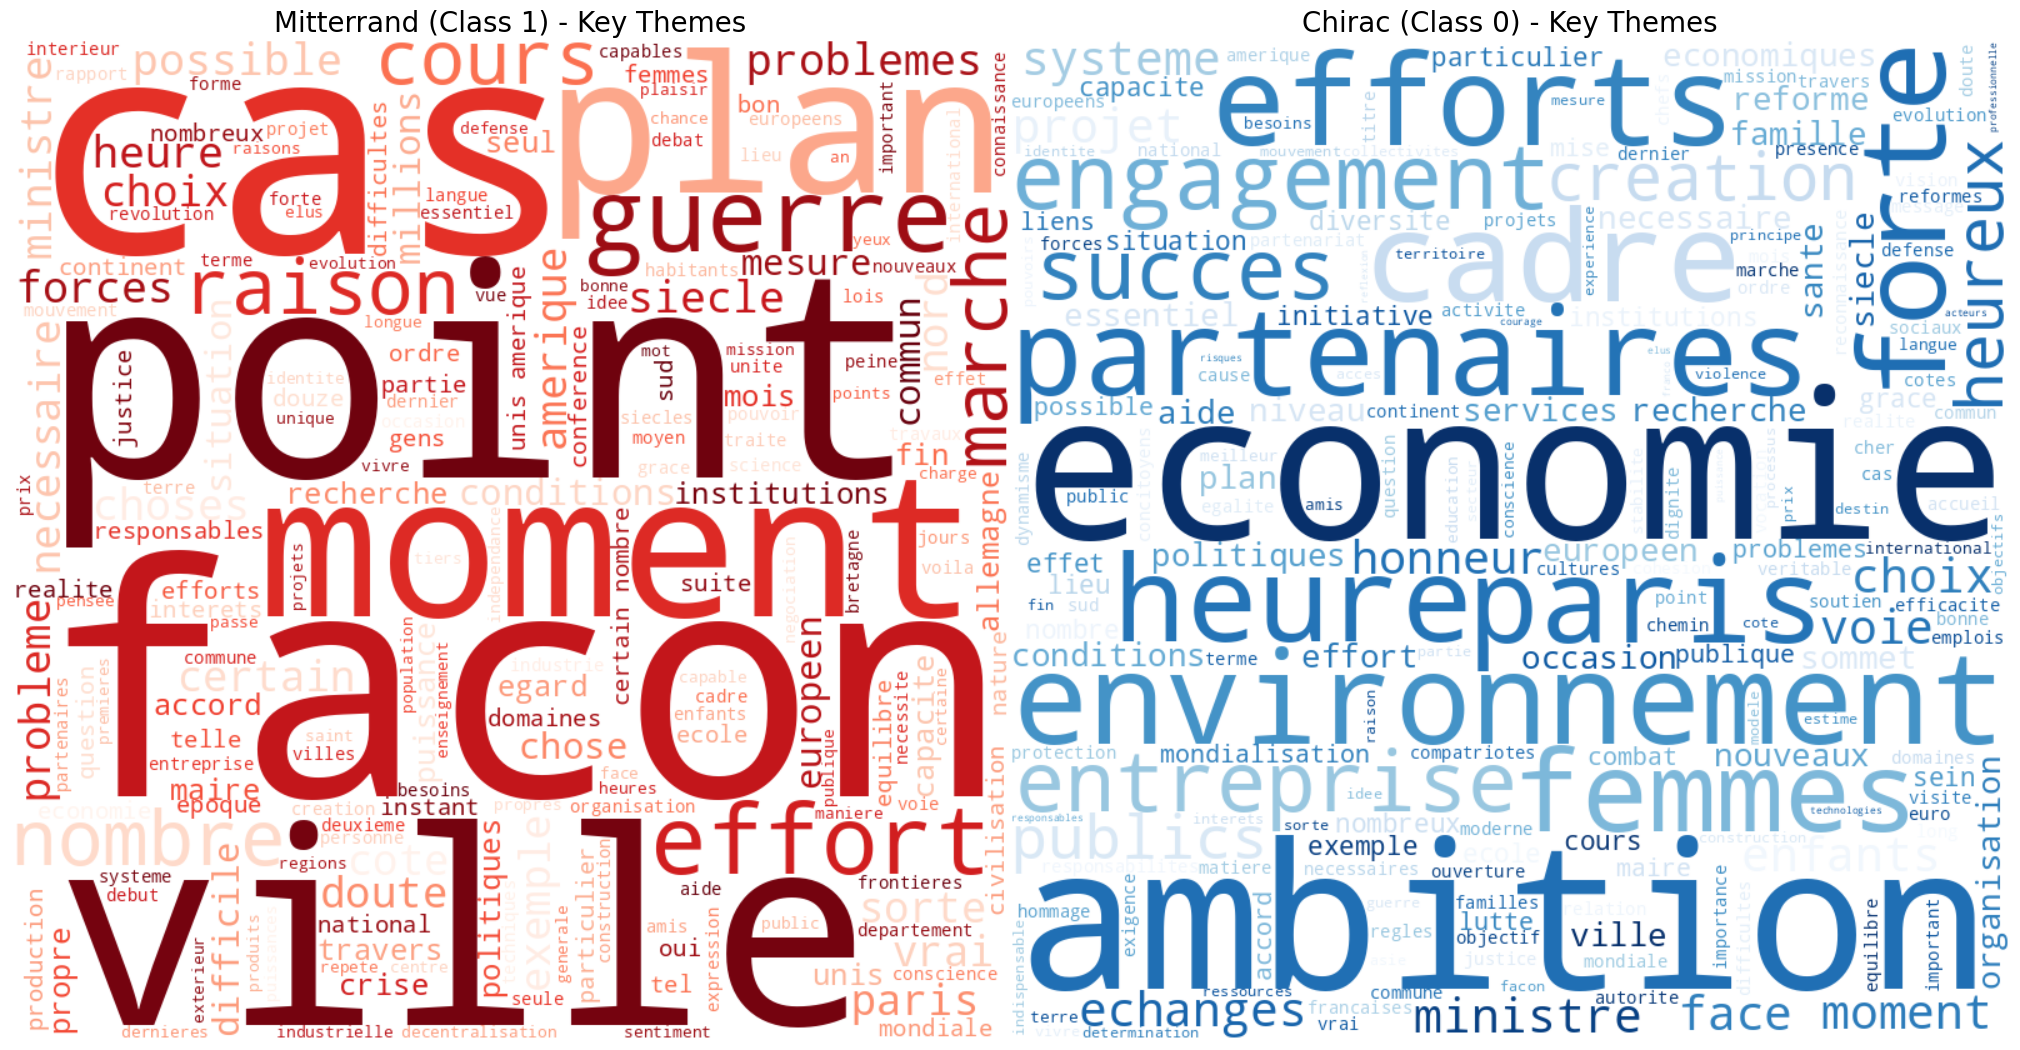

In [24]:
# Get the analyzer from your vectorizer (this contains your stop_words logic)
analyze = vectorizer.build_analyzer()

# Re-calculate counts using the analyzer
def get_cleaned_counts(text_list):
    counts = Counter()
    for doc in text_list:
        # analyze(doc) returns a list of tokens MINUS stopwords
        counts.update(analyze(doc))
    return counts

# Re-run for both classes
mitt_docs = [txt for txt, lab in zip(processed_txts_pos, alllabs) if lab == 1]
chri_docs = [txt for txt, lab in zip(processed_txts_pos, alllabs) if lab == 0]

mitt_counts_clean = get_cleaned_counts(mitt_docs)
chri_counts_clean = get_cleaned_counts(chri_docs)

# Generate the Word Clouds using the CLEAN counts
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# 1. Setup the WordCloud object
# We use the counts we already calculated (mitt_counts and chri_counts)
wc = WordCloud(
    width=800, 
    height=400, 
    background_color='white',
    max_words=100,
    colormap='RdBu' # Or 'Reds' for Mitt and 'Blues' for Chri
)

plt.figure(figsize=(20, 10))

# 2. Plot Mitterrand (Class 1)
plt.subplot(1, 2, 1)
# generate_from_frequencies is better than text because it uses our cleaned data
wordcloud_mitt = WordCloud(width=800, height=800, background_color='white', colormap='Reds').generate_from_frequencies(mitt_counts_clean)
plt.imshow(wordcloud_mitt, interpolation='bilinear')
plt.title("Mitterrand (Class 1) - Key Themes", fontsize=20)
plt.axis('off')

# 3. Plot Chirac (Class 0)
plt.subplot(1, 2, 2)
wordcloud_chri = WordCloud(width=800, height=800, background_color='white', colormap='Blues').generate_from_frequencies(chri_counts_clean)
plt.imshow(wordcloud_chri, interpolation='bilinear')
plt.title("Chirac (Class 0) - Key Themes", fontsize=20)
plt.axis('off')

plt.tight_layout(pad=0)
plt.show()

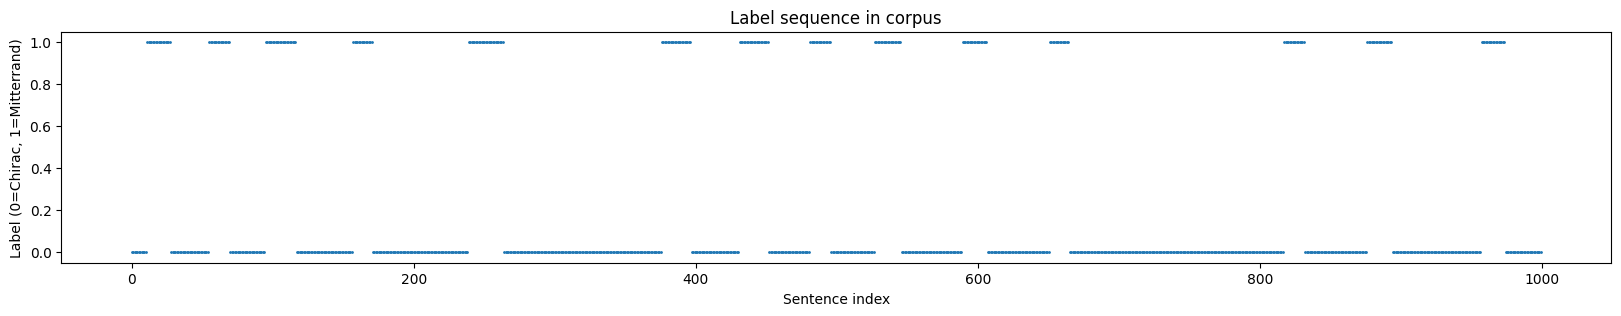

P(next=Mitterrand | current=Mitterrand): 0.947
P(next=Chirac | current=Mitterrand):     0.053
P(next=Chirac | current=Chirac):         0.992
P(next=Mitterrand | current=Chirac):     0.008


In [ ]:
import matplotlib.pyplot as plt

# Plot labels vs index
plt.figure(figsize=(20, 3))
plt.plot(alllabs[:1000], '.', markersize=2)  # first 1000 sentences
plt.xlabel('Sentence index')
plt.ylabel('Label (0=Chirac, 1=Mitterrand)')
plt.title('Label sequence in corpus')
#plt.savefig('label_sequence.png')
plt.show()

# If current=Mitterrand, what's probability next is also Mitterrand
transitions = {}
for i in range(len(alllabs)-1):
    key = (alllabs[i], alllabs[i+1])
    transitions[key] = transitions.get(key, 0) + 1

total_mitterrand = sum(v for k,v in transitions.items() if k[0]==1)
print(f"P(next=Mitterrand | current=Mitterrand): {transitions[(1,1)]/total_mitterrand:.3f}")
print(f"P(next=Chirac | current=Mitterrand):     {transitions[(1,0)]/total_mitterrand:.3f}")

total_chirac = sum(v for k,v in transitions.items() if k[0]==0)
print(f"P(next=Chirac | current=Chirac):         {transitions[(0,0)]/total_chirac:.3f}")
print(f"P(next=Mitterrand | current=Chirac):     {transitions[(0,1)]/total_chirac:.3f}")
